In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from PIL import Image
import pandas as pd
from tqdm import tqdm
import random
# from google.colab import drive
# drive.mount('/content/drive')

In [16]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    """Sets all relevant seeds for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Random seed set to: {seed}")
# Apply the seed
set_seed(42)

Random seed set to: 42


In [17]:
# PACS_ROOT = "/content/drive/MyDrive/PACS_dataset_suffled/PACS_dataset/"
# SOURCE_WEIGHTS_PATH = "/content/drive/MyDrive/PACS_dataset_suffled/models/resnet18_pacs_ACS_source.pth"
# TARGET_DOMAIN ="photo" # change as needed
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:",DEVICE)
BATCH_SIZE = 32
NUM_FREQ_BINS = 16
ALPHA_INIT = 0.07
LR_PROMPT = 2.5e-2
LAMBDA_REG = 0.5

using device: cuda


In [18]:
class PACS_CSV_Dataset(Dataset):
    def __init__(self, root_dir, domain, transform=None):
        self.root_dir, self.domain, self.transform = root_dir, domain, transform
        csv_path = os.path.join(root_dir, domain, 'labels.csv')
        self.data_info = pd.read_csv(csv_path)
        u_labels = sorted(self.data_info['label'].unique())
        self.label_to_idx = {label: i for i, label in enumerate(u_labels)}
    def __len__(self): return len(self.data_info)
    def __getitem__(self, idx):
        img_name = self.data_info.iloc[idx]['new_filename']
        img_path = os.path.join(self.root_dir, self.domain, img_name)
        image = Image.open(img_path).convert('RGB')
        label = self.label_to_idx[self.data_info.iloc[idx]['label']]
        if self.transform: image = self.transform(image)
        return image, label

def get_pacs_loaders(root, target, bs=32):
    t = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                             transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    domains = ['art_painting', 'cartoon', 'photo', 'sketch']
    target_ds = PACS_CSV_Dataset(root, target, transform=t)
    source_ds = ConcatDataset([PACS_CSV_Dataset(root, d, transform=t) for d in domains if d != target])
    return DataLoader(source_ds, bs, shuffle=True), DataLoader(target_ds, bs, shuffle=True)

In [19]:
CIFAR10C_ROOT = r"C:\Users\5520\Documents\IITH BTECH ENGINEERING\SEM 6\CV\Project\cifar10\cifar10\CIFAR-10-C"
SOURCE_WEIGHTS_PATH = r"C:\Users\5520\Documents\IITH BTECH ENGINEERING\SEM 6\CV\Project\cifar10\cifar10\resnet18_cifar10_source.pth"
CORRUPTION = "shot_noise" # change as needed (e.g., 'brightness', 'contrast')
SEVERITY = 3
print(f"Selected Corruption: {CORRUPTION}, Severity: {SEVERITY}")

Selected Corruption: shot_noise, Severity: 3


In [20]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CIFAR10C_Dataset(Dataset):
    def __init__(self, root_dir, corruption, severity, transform=None):
        """
        Args:
            root_dir: directory containing CIFAR-10-C .npy files (e.g. '.../CIFAR-10-C')
            corruption: name of the corruption (e.g. 'brightness', 'contrast')
            severity: integer from 1 to 5 (each severity has 10,000 images)
            transform: torchvision transforms
        """
        self.root_dir = root_dir
        self.corruption = corruption
        self.severity = severity
        self.transform = transform
        
        # Load the data and labels
        data_path = os.path.join(root_dir, f"{corruption}.npy")
        label_path = os.path.join(root_dir, "labels.npy")
        
        self.data_all = np.load(data_path)
        self.labels_all = np.load(label_path)
        
        # Extract the specific severity slice
        # In CIFAR-10-C, each severity level has exactly 10,000 continuous images
        start_idx = (severity - 1) * 10000
        end_idx = severity * 10000
        
        self.data = self.data_all[start_idx:end_idx]
        self.labels = self.labels_all[start_idx:end_idx]
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        # Convert np array (32, 32, 3) back to PIL Image for torchvision transforms
        image = self.data[idx]
        image = Image.fromarray(image).convert('RGB')
        label = int(self.labels[idx])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

def get_cifar10c_loaders(root, corruption, severity, bs=32):
    """
    Returns (None, target_loader) to match the expected output format of get_pacs_loaders.
    Since test-time adaptation only needs the target_loader, the source_loader is returned as None.
    """
    # Using the same transform sequence as the PACS loader in your notebook
    t = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    target_ds = CIFAR10C_Dataset(root, corruption, severity, transform=t)
    target_loader = DataLoader(target_ds, batch_size=bs, shuffle=True)
    
    # We return None for source_loader so you can just drop this in place of get_pacs_loaders
    return None, target_loader


In [21]:

class RadialFrequencyExtractor(nn.Module):
    def __init__(self, image_size=224, num_bins=16):
        super().__init__()
        self.num_bins = num_bins
        
        # 1. Precompute radial distance map
        y, x = torch.meshgrid(torch.arange(image_size), torch.arange(image_size), indexing='ij')
        center = image_size // 2
        r = torch.sqrt((x.float() - center)**2 + (y.float() - center)**2)
        max_r = torch.max(r)

        # 2. Precompute the Ring Masks
        masks = []
        for i in range(num_bins):
            r_min = i * (max_r / num_bins)
            r_max = (i + 1) * (max_r / num_bins)
            mask = (r >= r_min) & (r < r_max)
            masks.append(mask.float())

        # Register buffers so they handle GPU move automatically
        self.register_buffer('masks', torch.stack(masks)) # [16, 224, 224]
        self.register_buffer('masks_area', self.masks.sum(dim=(1, 2)) + 1e-8)

    def forward(self, x):
        # 1. 2D FFT & Shift (Matching your 'ortho' normalization)
        fft_out = torch.fft.fft2(x, dim=(-2, -1), norm='ortho')
        fft_shifted = torch.fft.fftshift(fft_out, dim=(-2, -1))
        
        amplitude = torch.abs(fft_shifted)
        phase = torch.angle(fft_shifted)

        # 2. Extract Channel-wise radial energy [B, 3, 16]
        # This gives 16 values for Red, 16 for Green, 16 for Blue = 48 total.
        mean_band_energy = torch.einsum('bchw,nhw->bcn', amplitude, self.masks) / self.masks_area
        
        return amplitude, phase, mean_band_energy


In [22]:
class FrequencyConditionedPrompter(nn.Module):
    def __init__(self, backbone, num_bins=16):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters(): p.requires_grad = False
        self.backbone.eval()
        
        self.extractor = RadialFrequencyExtractor(num_bins=num_bins)
        
        self.mlp = nn.Sequential(
            nn.Linear(3 * num_bins, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 3 * num_bins), 
            nn.Tanh()
        )
        nn.init.zeros_(self.mlp[-2].weight); nn.init.zeros_(self.mlp[-2].bias)
        self.alpha = nn.Parameter(torch.tensor([ALPHA_INIT]))


    def forward(self, x):
        amplitude, phase, band_energy = self.extractor(x)
        
        # 1. Generate multipliers
        raw_prompt = self.mlp(band_energy.view(x.shape[0], -1)).view(x.shape[0], 3, -1)

        prompt_vec = raw_prompt
        # 3. Expand to 2D mask
        prompt_2d = torch.einsum('bcn,nhw->bchw', prompt_vec, self.extractor.masks)

        # 4. Multiplicative adaptation
        new_amplitude = amplitude * (1 + self.alpha * prompt_2d)
        
        # 5. Signal Reconstruction (Euler's Formula)
        complex_freq = new_amplitude * torch.cos(phase.detach()) + 1j * (new_amplitude * torch.sin(phase.detach()))
        x_adapted = torch.fft.ifft2(torch.fft.ifftshift(complex_freq, dim=(-2, -1)), dim=(-2, -1), norm='ortho').real

        return self.backbone(x_adapted), prompt_vec


class InfoMaxLoss(nn.Module):
    def __init__(self, lambda_reg=LAMBDA_REG):
        super().__init__(); self.lambda_reg = lambda_reg
    def forward(self, logits, prompt_vec):
        probs = F.softmax(logits, dim=1)
        entropy = - (probs * F.log_softmax(logits, dim=1)).sum(dim=1)
        ent_loss =  entropy.mean()
        l2_penalty = torch.mean(prompt_vec ** 2)
        return ent_loss + (self.lambda_reg * l2_penalty), ent_loss, l2_penalty

In [23]:
# Initialize Backbone
source_loader, target_loader = get_cifar10c_loaders(CIFAR10C_ROOT, CORRUPTION, SEVERITY, BATCH_SIZE)

backbone = models.resnet18(pretrained=False)
backbone.fc = nn.Linear(backbone.fc.in_features, 10)
ckpt = torch.load(SOURCE_WEIGHTS_PATH, map_location=DEVICE)

# Extract the actual model weights (handles both nested and direct checkpoints)
if 'model_state_dict' in ckpt:
    state_dict = ckpt['model_state_dict']
elif 'state_dict' in ckpt:
    state_dict = ckpt['state_dict']
else:
    state_dict = ckpt

# Handle "module." prefix from models saved with DataParallel
if list(state_dict.keys())[0].startswith('module.'): 
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

backbone.load_state_dict(state_dict)
backbone = backbone.to(DEVICE)


C:\Users\5520\AppData\Local\Temp\ipykernel_46196\2293596835.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(SOURCE_WEIGHTS_PATH, map_location=DEVICE)


In [24]:
tta_model = FrequencyConditionedPrompter(backbone).to(DEVICE)
optimizer = torch.optim.AdamW([{'params': tta_model.mlp.parameters(), 'lr': LR_PROMPT},
                               {'params': tta_model.alpha, 'lr': 1e-2}], weight_decay=1e-4)
criterion = InfoMaxLoss(lambda_reg=LAMBDA_REG)

correct, total = 0, 0
loop = tqdm(target_loader, desc=f"Safe Online TTA")

for images, labels in loop:
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    optimizer.zero_grad(set_to_none=True)
    
    logits, prompt_vec = tta_model(images)
    # mask = (F.softmax(logits, dim=1).max(dim=1)[0] > CONFIDENCE_THRESH)
    
    # loss, ent_val, l2_val = criterion(logits, prompt_vec, mask=mask)
    loss, ent_val, l2_val = criterion(logits, prompt_vec)
    loss.backward() # Scaled by ENTROPY_WEIGHT
    optimizer.step()

    total += labels.size(0); correct += logits.max(1)[1].eq(labels).sum().item()
    loop.set_postfix({'Acc': f"{100.*correct/total:.2f}%", 'Ent': f"{ent_val.item():.4f}", 'L2': f"{l2_val.item():.4f}"})

print(f"\nCompleted Online TTA.")
print(f"Final Accuracy: {100. * correct / total}%")

Safe Online TTA: 100%|██████████| 313/313 [00:52<00:00,  5.92it/s, Acc=66.43%, Ent=0.4077, L2=0.0309]


Completed Online TTA.
Final Accuracy: 66.43%


In [25]:
def evaluate_baseline(model, dataloader, device):
    """Evaluates the source model without any Test-Time Adaptation."""
    model.eval()
    correct, total = 0, 0
    
    print(f"Evaluating Baseline Performance...")
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Baseline Eval"):
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            _, predicted = logits.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    acc = 100. * correct / total
    print(f"--> Baseline Accuracy: {acc}%\n")
    return acc

# --- RUN BASELINE EVALUATION ---
baseline_acc = evaluate_baseline(backbone, target_loader, DEVICE)


Evaluating Baseline Performance...


Baseline Eval: 100%|██████████| 313/313 [00:24<00:00, 12.76it/s]

--> Baseline Accuracy: 50.07%



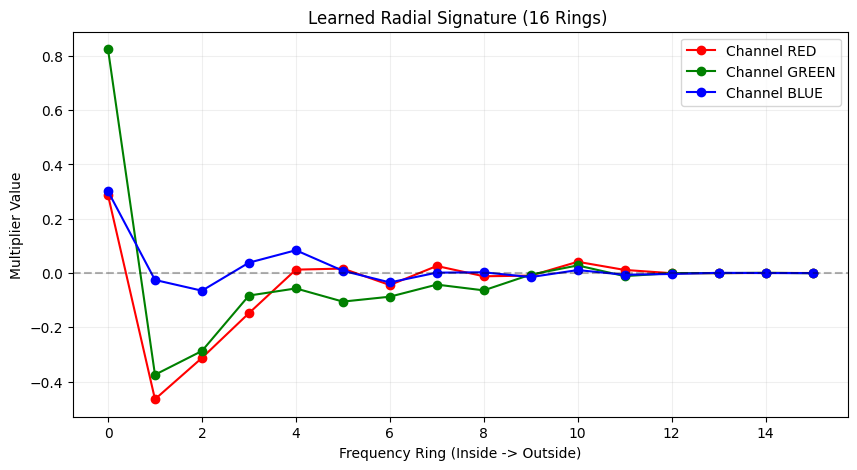

In [26]:
def visualize_radial_signature(model):
    """Plots the 16 bin multipliers for R, G, and B."""
    model.eval()
    images, _ = next(iter(target_loader))
    images = images.to(DEVICE)
    
    with torch.no_grad():
        _, _, band_energy = model.extractor(images)
        # Get the multipliers [B, 3, 16]
        raw_prompt = model.mlp(band_energy.view(images.shape[0], -1)).view(images.shape[0], 3, -1)
        # prompt_vec = (raw_prompt * model.dc_mask).mean(dim=0).cpu().numpy()
        prompt_vec = (raw_prompt).mean(dim=0).cpu().numpy()

    plt.figure(figsize=(10, 5))
    bins = np.arange(16)
    colors = ['red', 'green', 'blue']
    for i, col in enumerate(colors):
        plt.plot(bins, prompt_vec[i], label=f'Channel {col.upper()}', color=col, marker='o')
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.title(f"Learned Radial Signature (16 Rings) ")
    plt.xlabel("Frequency Ring (Inside -> Outside)")
    plt.ylabel("Multiplier Value")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

visualize_radial_signature(tta_model)


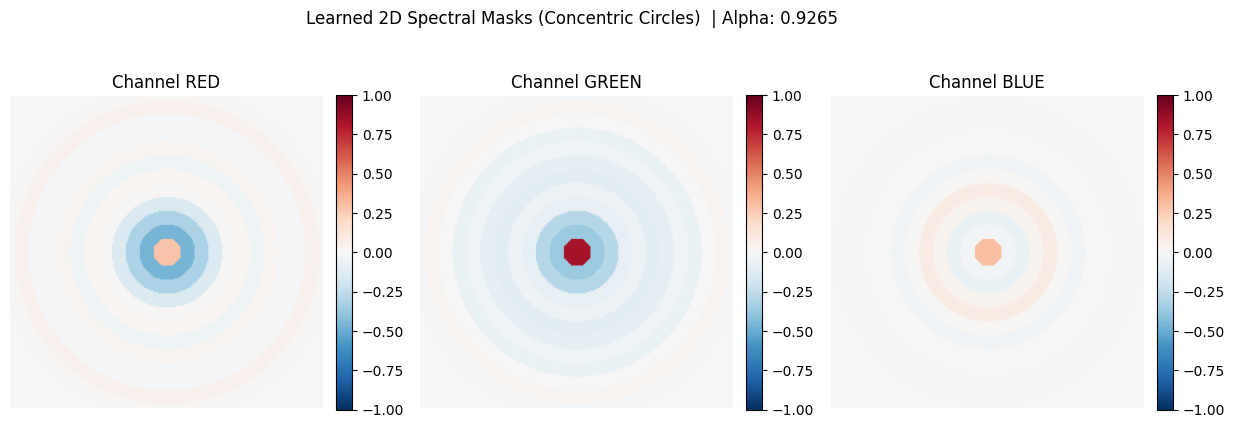

In [27]:
def visualize_radial_heatmaps(model):
    """Visualizes the 2D circular masks applied to the frequency domain."""
    model.eval()
    images, _ = next(iter(target_loader))
    images = images.to(DEVICE)
    
    with torch.no_grad():
        _, _, band_energy = model.extractor(images)
        raw_prompt = model.mlp(band_energy.view(images.shape[0], -1)).view(images.shape[0], 3, -1)
        alpha_val = model.alpha.item()
        # prompt_vec = raw_prompt * model.dc_mask
        prompt_vec = raw_prompt 
        # Expand 1D bins to 2D rings [B, C, H, W]
        prompt_2d = torch.einsum('bcn,nhw->bchw', prompt_vec, model.extractor.masks)
        mean_prompt_2d = prompt_2d.mean(dim=0).cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    plt.suptitle(f"Learned 2D Spectral Masks (Concentric Circles)  | Alpha: {alpha_val:.4f}")
    
    for i, col in enumerate(['RED', 'GREEN', 'BLUE']):
        im = axes[i].imshow(mean_prompt_2d[i], cmap='RdBu_r', vmin=-1, vmax=1)
        axes[i].set_title(f"Channel {col}")
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        
    plt.show()

visualize_radial_heatmaps(tta_model)


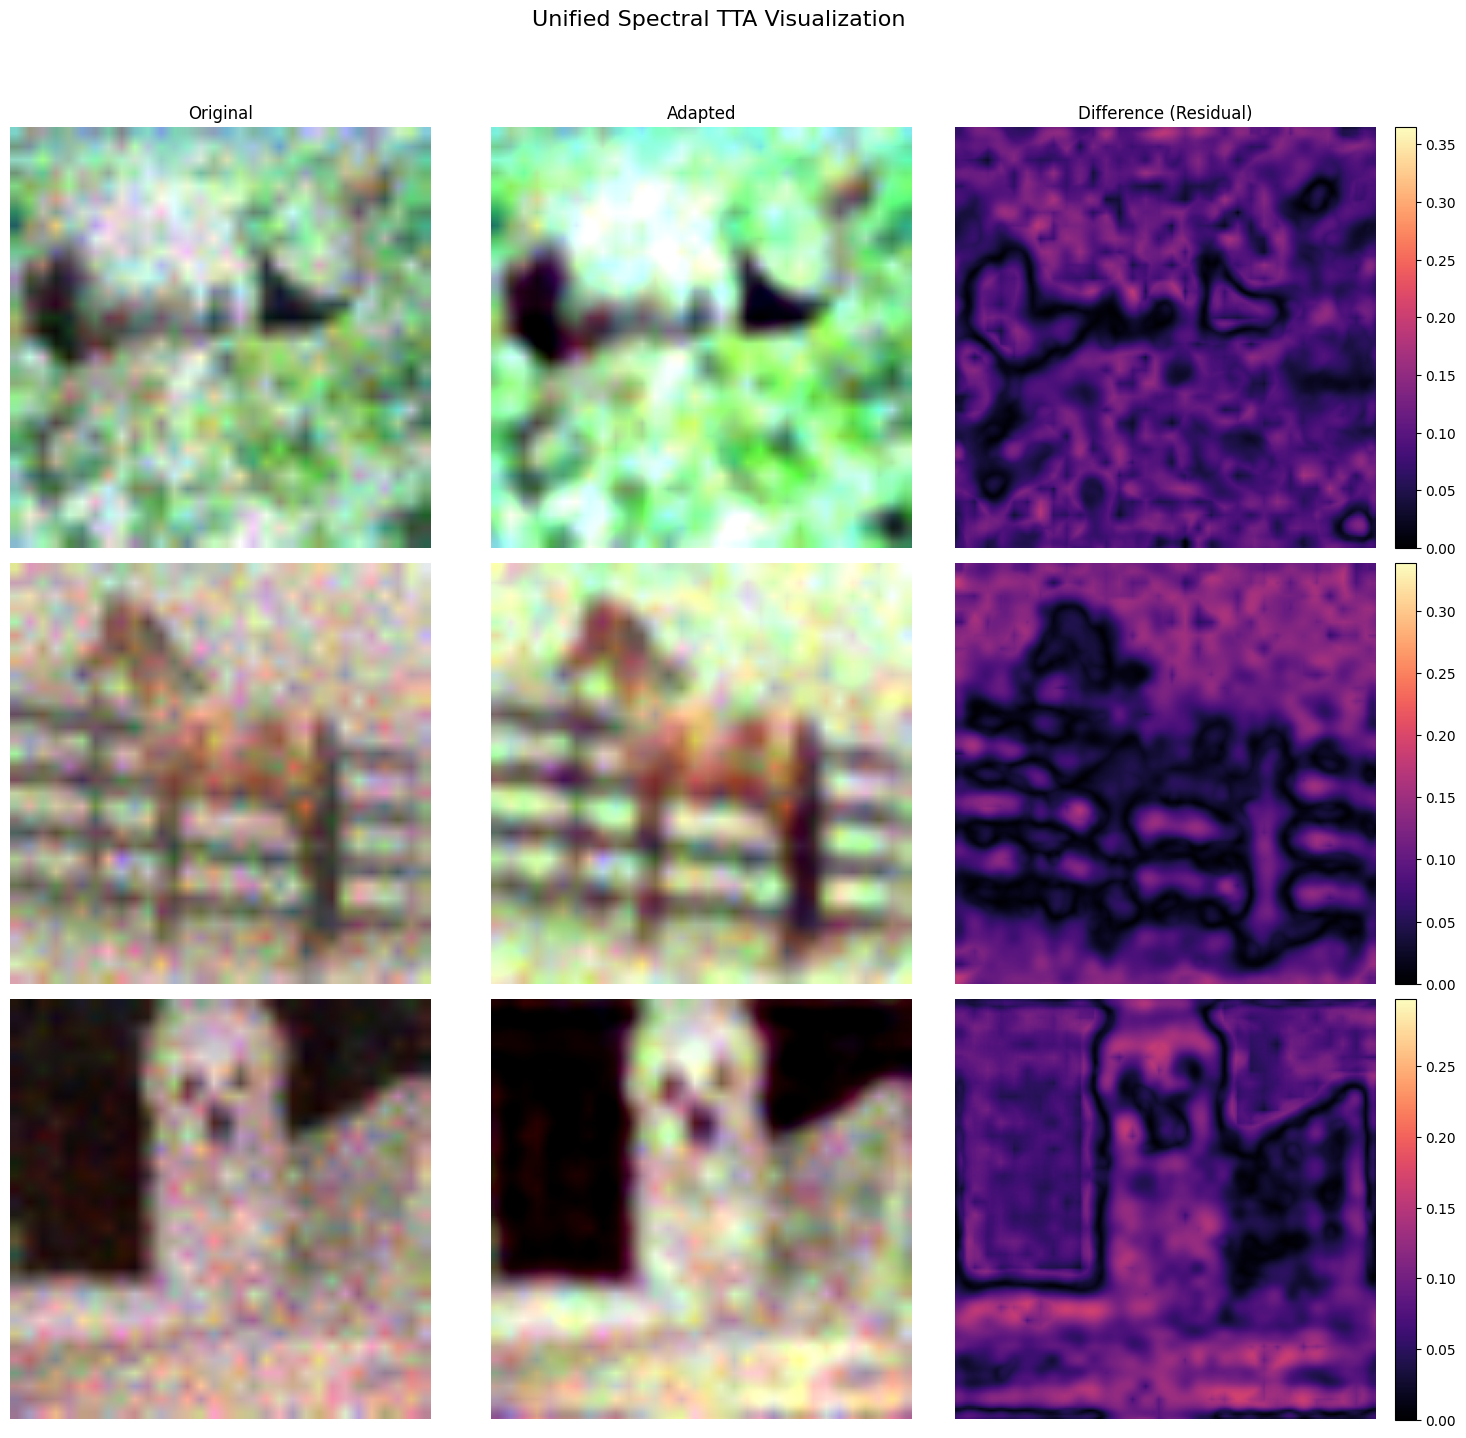

In [28]:
def visualize_full_tta_comparison(model, dataloader, device, num_samples=3):
    """Plots Original | Adapted | Difference (Residual) side-by-side."""
    model.eval()
    images, labels = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        amplitude, phase, band_energy = model.extractor(images)
        raw_prompt = model.mlp(band_energy.view(images.shape[0], -1)).view(images.shape[0], 3, -1)
        # prompt_vec = raw_prompt * model.dc_mask
        prompt_vec = raw_prompt
        prompt_2d = torch.einsum('bcn,nhw->bchw', prompt_vec, model.extractor.masks)
        
        new_amplitude = amplitude * (1 + model.alpha * prompt_2d)
        complex_freq = new_amplitude * torch.cos(phase.detach()) + 1j * (new_amplitude * torch.sin(phase.detach()))
        adapted_images = torch.fft.ifft2(torch.fft.ifftshift(complex_freq, dim=(-2, -1)), dim=(-2, -1), norm='ortho').real

    inv_norm = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    actual_samples = min(num_samples, images.size(0))
    # Changed from 4 columns to 3
    fig, axes = plt.subplots(actual_samples, 3, figsize=(15, 5 * actual_samples))
    if actual_samples == 1: axes = np.expand_dims(axes, axis=0)

    plt.suptitle(f"Unified Spectral TTA Visualization ", fontsize=16)

    # Removed "Spectral Prompt (Mask)" from columns
    cols = ["Original", "Adapted", "Difference (Residual)"]
    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=12)

    for i in range(actual_samples):
        # 1. Original Image
        orig = inv_norm(images[i]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
        axes[i, 0].imshow(orig)
        axes[i, 0].axis('off')

        # 2. Adapted Image (Moved from index 2 to 1)
        adapted = inv_norm(adapted_images[i]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
        axes[i, 1].imshow(adapted)
        axes[i, 1].axis('off')

        # 3. Difference/Residual (Moved from index 3 to 2)
        diff = np.abs(orig - adapted)
        v_min, v_max = diff.min(), diff.max()
        # diff = (diff / (diff.max() + 1e-8)) 
        im_diff=axes[i, 2].imshow(diff.mean(axis=2), cmap='magma' ,vmin=v_min, vmax=v_max)
        axes[i, 2].axis('off')
        plt.colorbar(im_diff, ax=axes[i, 2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the updated visualization
visualize_full_tta_comparison(tta_model, target_loader, DEVICE)
